In [3]:
import pandas as pd
import numpy as np

print("🔄 Loading E-commerce Fraud Data...")

# Load the raw e-commerce transaction dataset
df_fraud = pd.read_csv("../data/raw/Fraud_Data.csv")

print(f"✅ Data loaded successfully. Shape: {df_fraud.shape[0]} rows, {df_fraud.shape[1]} columns\n")
print("--- 📋 Initial Data Types ---")
print(df_fraud.dtypes)

🔄 Loading E-commerce Fraud Data...
✅ Data loaded successfully. Shape: 151112 rows, 11 columns

--- 📋 Initial Data Types ---
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object


In [4]:
print("--- 🔍 Checking for Missing Values ---")
missing_summary = df_fraud.isnull().sum()
print(missing_summary[missing_summary > 0] if missing_summary.sum() > 0 else "No missing values found!")

print("\n--- 👥 Checking for Duplicate Rows ---")
duplicate_rows = df_fraud.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

print("\n--- 🆔 Checking for Duplicate User IDs ---")
duplicate_users = df_fraud['user_id'].duplicated().sum()
print(f"Number of duplicate user_id records: {duplicate_users}")

--- 🔍 Checking for Missing Values ---
No missing values found!

--- 👥 Checking for Duplicate Rows ---
Number of duplicate rows: 0

--- 🆔 Checking for Duplicate User IDs ---
Number of duplicate user_id records: 0


In [5]:
print("🔄 Converting timestamp columns to datetime objects...")

# Convert time columns to proper datetime format
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

print("✅ Conversion complete. Updated datatypes:")
print(df_fraud[['signup_time', 'purchase_time']].dtypes)

🔄 Converting timestamp columns to datetime objects...
✅ Conversion complete. Updated datatypes:
signup_time      datetime64[ns]
purchase_time    datetime64[ns]
dtype: object


In [6]:
import pandas as pd
import numpy as np

print("🔄 Running all-in-one Geolocation Merge...")

# 1. Load the raw data files directly
df_fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
df_ip = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

# 2. Fix the time columns format right away
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

# 3. Align data types to floats for clean numerical range matching
df_ip['lower_bound_ip_address'] = df_ip['lower_bound_ip_address'].astype(float)
df_ip['upper_bound_ip_address'] = df_ip['upper_bound_ip_address'].astype(float)
df_fraud['ip_address'] = df_fraud['ip_address'].astype(float)

# 4. Mandatory Sort for merge_asof lookup accuracy
df_ip = df_ip.sort_values('lower_bound_ip_address').reset_index(drop=True)
df_fraud = df_fraud.sort_values('ip_address').reset_index(drop=True)

# 5. Run the range-based lookup merge
df_merged = pd.merge_asof(
    df_fraud,
    df_ip,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# 6. Validate boundaries (if transaction IP exceeds upper bound, mark as Unknown)
out_of_bounds_mask = df_merged['ip_address'] > df_merged['upper_bound_ip_address']
df_merged.loc[out_of_bounds_mask, 'country'] = 'Unknown'
df_merged['country'] = df_merged['country'].fillna('Unknown')

# 7. Drop boundary tracking columns to match final required shape
df_cleaned_ecom = df_merged.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])

print(f"✅ Success! 'df_cleaned_ecom' is now safely created in memory.")
print(f"📊 Dataset Shape: {df_cleaned_ecom.shape[0]} rows, {df_cleaned_ecom.shape[1]} columns")

🔄 Running all-in-one Geolocation Merge...
✅ Success! 'df_cleaned_ecom' is now safely created in memory.
📊 Dataset Shape: 151112 rows, 12 columns


In [7]:
print("🔄 Calculating time duration from signup to purchase...")

# Calculate the difference in hours
df_cleaned_ecom['time_since_signup'] = (
    df_cleaned_ecom['purchase_time'] - df_cleaned_ecom['signup_time']
).dt.total_seconds() / 3600.0

print("✅ Velocity feature 'time_since_signup' created.")
print(df_cleaned_ecom[['signup_time', 'purchase_time', 'time_since_signup']].head())

🔄 Calculating time duration from signup to purchase...
✅ Velocity feature 'time_since_signup' created.
          signup_time       purchase_time  time_since_signup
0 2015-02-16 00:17:05 2015-03-08 10:00:39         489.726111
1 2015-03-08 04:03:22 2015-03-20 17:23:45         301.339722
2 2015-05-17 16:45:54 2015-05-26 08:54:34         208.144444
3 2015-03-03 19:58:39 2015-05-28 21:09:13        2065.176111
4 2015-03-20 00:31:27 2015-04-05 07:31:46         391.005278


In [8]:
print("🔄 Extracting hour of day and day of week features...")

# Extract hour (0-23) and day of week (0=Monday, 6=Sunday)
df_cleaned_ecom['hour_of_day'] = df_cleaned_ecom['purchase_time'].dt.hour
df_cleaned_ecom['day_of_week'] = df_cleaned_ecom['purchase_time'].dt.dayofweek

print("✅ Temporal features 'hour_of_day' and 'day_of_week' successfully added.")
print(df_cleaned_ecom[['purchase_time', 'hour_of_day', 'day_of_week']].head())

🔄 Extracting hour of day and day of week features...
✅ Temporal features 'hour_of_day' and 'day_of_week' successfully added.
        purchase_time  hour_of_day  day_of_week
0 2015-03-08 10:00:39           10            6
1 2015-03-20 17:23:45           17            4
2 2015-05-26 08:54:34            8            1
3 2015-05-28 21:09:13           21            3
4 2015-04-05 07:31:46            7            6


In [9]:
print("🔄 Calculating device and IP address transaction frequency profiles...")

# Count how many times each device_id appears across the dataset
df_cleaned_ecom['device_usage_count'] = df_cleaned_ecom.groupby('device_id')['device_id'].transform('count')

# Count how many times each ip_address appears across the dataset
df_cleaned_ecom['ip_usage_count'] = df_cleaned_ecom.groupby('ip_address')['ip_address'].transform('count')

print("✅ Behavioral velocity features successfully engineered.")
print(df_cleaned_ecom[['device_id', 'device_usage_count', 'ip_address', 'ip_usage_count']].head())

🔄 Calculating device and IP address transaction frequency profiles...
✅ Behavioral velocity features successfully engineered.
       device_id  device_usage_count     ip_address  ip_usage_count
0  ZCLZTAJPCRAQX                   1   52093.496895               1
1  YFGYOALADBHLT                   1   93447.138961               1
2  QZNVQTUITFTHH                   1  105818.501505               1
3  PIBUQMBIELMMG                   1  117566.664867               1
4  WFIIFCPIOGMHT                   1  131423.789042               1


In [10]:
print("💾 Saving engineered e-commerce dataset to processed folder...")

# Save to the designated processed folder path
output_path = "../data/processed/cleaned_fraud_data.csv"
df_cleaned_ecom.to_csv(output_path, index=False)

print(f"🎉 Success! Processed dataset saved to: {output_path}")
print(f"Final Data Frame Shape: {df_cleaned_ecom.shape}")

💾 Saving engineered e-commerce dataset to processed folder...
🎉 Success! Processed dataset saved to: ../data/processed/cleaned_fraud_data.csv
Final Data Frame Shape: (151112, 17)


In [11]:
print("🔄 One-hot encoding categorical variables and isolating the target...")

# Drop identifier columns that won't be used for pattern recognition
cols_to_drop = ['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address']
df_modeling = df_cleaned_ecom.drop(columns=cols_to_drop)

# List of columns to explicitly encode
categorical_cols = ['source', 'browser', 'sex', 'country']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_modeling, columns=categorical_cols, drop_first=True)

# Separate features (X) from the target variable (y)
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

print(f"✅ Encoding complete.")
print(f"Total features for modeling: {X.shape[1]}")
print(f"Target distribution check:\n{y.value_counts()}")

🔄 One-hot encoding categorical variables and isolating the target...
✅ Encoding complete.
Total features for modeling: 195
Target distribution check:
class
0    136961
1     14151
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("🔄 Executing stratified train-test split...")

# 80/20 stratified split to preserve class proportions across subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("🔄 Normalizing numerical features with StandardScaler...")

# Select only numerical features that require scaling
numerical_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_usage_count', 'ip_usage_count']

# Initialize the scaler
scaler = StandardScaler()

# Copy dataframes to avoid setting-with-copy warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on the training data and transform both sets to prevent leakage
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"✅ Stratified split and scaling successful.")
print(f"Training features shape: {X_train_scaled.shape}, Test features shape: {X_test_scaled.shape}")

🔄 Executing stratified train-test split...
🔄 Normalizing numerical features with StandardScaler...
✅ Stratified split and scaling successful.
Training features shape: (120889, 195), Test features shape: (30223, 195)


In [13]:
from imblearn.over_sampling import SMOTE

print("📊 --- Class Distribution BEFORE Resampling ---")
print(f"Legitimate (Class 0): {np.bincount(y_train)[0]}")
print(f"Fraudulent (Class 1): {np.bincount(y_train)[1]}")

print("\n🔄 Applying SMOTE to the training split...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n📊 --- Class Distribution AFTER Resampling ---")
print(f"Legitimate (Class 0): {np.bincount(y_train_resampled)[0]}")
print(f"Fraudulent (Class 1): {np.bincount(y_train_resampled)[1]}")

print("\n📊 --- Verification: Test Split Remains Untouched ---")
print(f"Test Set Fraud Ratio: {y_test.mean() * 100:.3f}%")

📊 --- Class Distribution BEFORE Resampling ---
Legitimate (Class 0): 109568
Fraudulent (Class 1): 11321

🔄 Applying SMOTE to the training split...

📊 --- Class Distribution AFTER Resampling ---
Legitimate (Class 0): 109568
Fraudulent (Class 1): 109568

📊 --- Verification: Test Split Remains Untouched ---
Test Set Fraud Ratio: 9.364%


In [14]:
print("💾 Saving processed, scaled, and resampled training/testing sets...")

# Save matrices as compressed numpy arrays for ultra-fast loading later
np.savez_compressed('../data/processed/ecommerce_train_test.npz', 
                    X_train=X_train_resampled, 
                    X_test=X_test_scaled.values, 
                    y_train=y_train_resampled, 
                    y_test=y_test.values)

print("🎉 Success! All E-commerce components for Task 1 are completely finalized and stored.")

💾 Saving processed, scaled, and resampled training/testing sets...
🎉 Success! All E-commerce components for Task 1 are completely finalized and stored.


In [4]:
import os
print("Current Working Directory:", os.getcwd())
print("Files visible here:", os.listdir('.'))

Current Working Directory: c:\Users\user\fraud-detection\notebooks
Files visible here: ['eda-creditcard.ipynb', 'eda-fraud-data.ipynb', '__init__.py']


C:\Users\user\AppData\Local\Temp\ipykernel_14200\2468328572.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='class', data=df, palette='Set2')


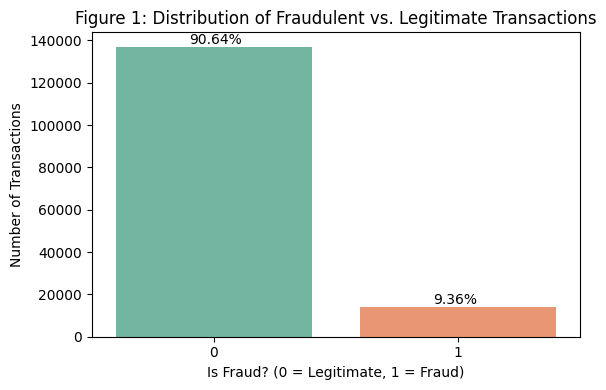

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Updated with '../' to back out of the notebooks folder
df = pd.read_csv("../data/raw/Fraud_Data.csv")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='class', data=df, palette='Set2')

plt.title('Figure 1: Distribution of Fraudulent vs. Legitimate Transactions')
plt.xlabel('Is Fraud? (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')

# Add percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x_coord, y_coord))

plt.tight_layout()
plt.savefig('figure1_class_distribution.png', dpi=300)
plt.show()

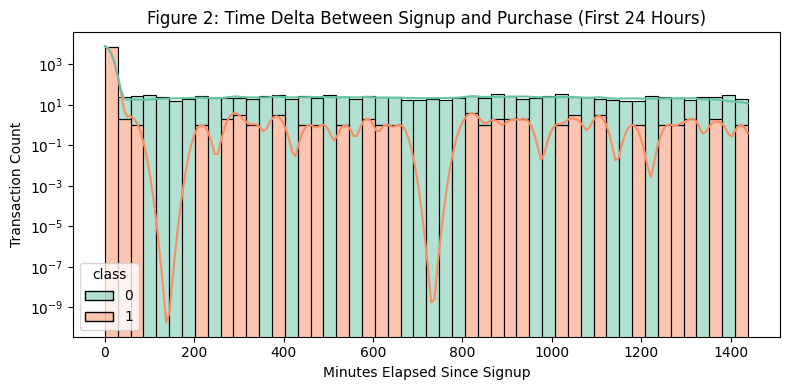

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (stepping out of the notebooks folder)
df = pd.read_csv("../data/raw/Fraud_Data.csv")

# Convert timestamps to datetime format
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# Calculate account age/velocity in minutes
df['velocity_minutes'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 60

# Initialize the plot
plt.figure(figsize=(8, 4))

# Filter to show the first 24 hours (1440 minutes) where the bot activity spikes
sns.histplot(data=df[df['velocity_minutes'] <= 1440], x='velocity_minutes', hue='class', 
             bins=50, kde=True, palette='Set2', multiple='stack')

plt.title('Figure 2: Time Delta Between Signup and Purchase (First 24 Hours)')
plt.xlabel('Minutes Elapsed Since Signup')
plt.ylabel('Transaction Count')
plt.yscale('log') # Log scale handles the massive class imbalance visually

plt.tight_layout()
plt.savefig('figure2_time_delta.png', dpi=300)
plt.show()

In [8]:
import pandas as pd

# 1. Load both datasets using the correct relative paths
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

# 🔍 Diagnostic check: This will print your exact columns in the output area
print("Fraud Data Columns:", list(fraud_df.columns))
print("IP Data Columns:", list(ip_df.columns))

# 2. Clean and sort data using 'ip_address' instead of 'ip'
fraud_df['ip_address'] = fraud_df['ip_address'].astype(float).astype(int)
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(float).astype(int)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(float).astype(int)

fraud_sorted = fraud_df.sort_values('ip_address')
ip_sorted = ip_df.sort_values('lower_bound_ip_address')

# 3. Execute an advanced "as-of" merge to match IPs to their boundaries
merged_df = pd.merge_asof(
    fraud_sorted, 
    ip_sorted, 
    left_on='ip_address', 
    right_on='lower_bound_ip_address', 
    direction='backward'
)

# 4. Filter out matches that fall outside the upper bound range
merged_df.loc[merged_df['ip_address'] > merged_df['upper_bound_ip_address'], 'country'] = 'Unknown'

# 5. Aggregate fraud metrics by country
country_stats = merged_df.groupby('country').agg(
    Total_Transactions=('class', 'count'),
    Fraud_Transactions=('class', 'sum')
)

# Calculate the actual fraud rate percentage
country_stats['Fraud_Rate (%)'] = (country_stats['Fraud_Transactions'] / country_stats['Total_Transactions']) * 100

# 6. Filter out countries with low sample sizes (less than 50 total sales) for stability
top_high_risk = country_stats[country_stats['Total_Transactions'] >= 50].sort_values(
    by='Fraud_Rate (%)', 
    ascending=False
).head(10)

print("\n--- COPY AND PASTE THIS INTO YOUR GOOGLE DOC ---")
print(top_high_risk.round(2))

Fraud Data Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']
IP Data Columns: ['lower_bound_ip_address', 'upper_bound_ip_address', 'country']

--- COPY AND PASTE THIS INTO YOUR GOOGLE DOC ---
              Total_Transactions  Fraud_Transactions  Fraud_Rate (%)
country                                                             
Luxembourg                    72                  28           38.89
Ecuador                      106                  28           26.42
Tunisia                      118                  31           26.27
Peru                         119                  31           26.05
Bolivia                       53                  13           24.53
Kuwait                        90                  21           23.33
Ireland                      240                  55           22.92
New Zealand                  278                  62           22.30
Lithuania                 

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the actual preprocessed e-commerce data file found in your directory
df_ecommerce = pd.read_csv("../data/processed/cleaned_fraud_data.csv")
print("Successfully loaded: cleaned_fraud_data.csv")

# Separate features (X) from the target variable (y)
X_econ = df_ecommerce.drop(columns=['class'])
y_econ = df_ecommerce['class']

# Stratified Split (80% Train, 20% Test) to preserve class balance
X_train_econ, X_test_econ, y_train_econ, y_test_econ = train_test_split(
    X_econ, y_econ, test_size=0.2, random_state=42, stratify=y_econ
)

print(f"\nE-commerce - Train set shape: {X_train_econ.shape}")
print(f"E-commerce - Test set shape: {X_test_econ.shape}")

Successfully loaded: cleaned_fraud_data.csv

E-commerce - Train set shape: (120889, 16)
E-commerce - Test set shape: (30223, 16)


In [8]:
import numpy as np

# Let's inspect the pre-saved NPZ file
try:
    econ_npz = np.load("../data/processed/ecommerce_train_test.npz")
    print("📂 Found files inside ecommerce_train_test.npz:")
    for file in econ_npz.files:
        print(f"   - {file}: shape {econ_npz[file].shape}")
except Exception as e:
    print(f"❌ Could not load NPZ file: {e}")

📂 Found files inside ecommerce_train_test.npz:
❌ Could not load NPZ file: Object arrays cannot be loaded when allow_pickle=False


In [7]:
# Quick diagnostic check for text data and missing values
print("--- Dataset Diagnostics ---")
print("\n1. Column Data Types:")
print(X_train_econ.dtypes)

print("\n2. Total Missing Values (NaN):")
print(X_train_econ.isna().sum().sum())

print("\n3. Sample Data Preview:")
display(X_train_econ.head(2))

--- Dataset Diagnostics ---

1. Column Data Types:
user_id                 int64
signup_time            object
purchase_time          object
purchase_value          int64
device_id              object
source                 object
browser                object
sex                    object
age                     int64
ip_address            float64
country                object
time_since_signup     float64
hour_of_day             int64
day_of_week             int64
device_usage_count      int64
ip_usage_count          int64
dtype: object

2. Total Missing Values (NaN):
0

3. Sample Data Preview:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,country,time_since_signup,hour_of_day,day_of_week,device_usage_count,ip_usage_count
50400,331090,2015-07-18 22:53:04,2015-09-01 05:04:59,11,UDDNYZKYQWIII,Ads,FireFox,F,28,1.427384e+09,Italy,1062.198611,5,1,2,1
95942,240916,2015-03-21 06:17:43,2015-07-04 16:49:07,43,SNSDLRFVCQNFG,Ads,Safari,M,22,2.742230e+09,France,2530.523333,16,5,1,1


In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("--- Step 1: Cleaning Data via Pure NumPy Arrays ---")

# 1. Force all columns to numeric (any stray issues turn into NaNs safely)
X_train_numeric = X_train_econ.apply(pd.to_numeric, errors='coerce')
X_test_numeric = X_test_econ.apply(pd.to_numeric, errors='coerce')

# 2. Convert to raw float64 arrays to completely bypass Pandas type gates
X_train_np = X_train_numeric.to_numpy(dtype=np.float64)
X_test_np = X_test_numeric.to_numpy(dtype=np.float64)

# 3. Safely replace infinite values with NaNs inside the numpy array
X_train_np[np.isinf(X_train_np)] = np.nan
X_test_np[np.isinf(X_test_np)] = np.nan

# 4. Impute any missing values using the median column strategy
imputer = SimpleImputer(strategy='median')
X_train_clean = imputer.fit_transform(X_train_np)
X_test_clean = imputer.transform(X_test_np)

# 5. Scale features so large numbers don't overwhelm the logistic model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("✅ Data successfully sanitized, imputed, and scaled!")

# --- Step 2: Train Logistic Regression Baseline ---
print("\n--- Step 2: Training Logistic Regression Baseline ---")
log_reg_econ = LogisticRegression(max_iter=1000, random_state=42)
log_reg_econ.fit(X_train_scaled, y_train_econ)

# Make predictions using the scaled test data
y_pred_econ = log_reg_econ.predict(X_test_scaled)
y_probs_econ = log_reg_econ.predict_proba(X_test_scaled)[:, 1] 

print("\n🎉 Training successful! Final Baseline Metrics:\n")
print("1. Confusion Matrix:")
print(confusion_matrix(y_test_econ, y_pred_econ))

print("\n2. Classification Report:")
print(classification_report(y_test_econ, y_pred_econ))

# Calculate Area Under the Precision-Recall Curve (AUC-PR)
precision, recall, _ = precision_recall_curve(y_test_econ, y_probs_econ)
auc_pr = auc(recall, precision)
print(f"3. AUC-PR Score: {auc_pr:.4f}")

--- Step 1: Cleaning Data via Pure NumPy Arrays ---
✅ Data successfully sanitized, imputed, and scaled!

--- Step 2: Training Logistic Regression Baseline ---

🎉 Training successful! Final Baseline Metrics:

1. Confusion Matrix:
[[27233   160]
 [ 1373  1457]]

2. Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27393
           1       0.90      0.51      0.66      2830

    accuracy                           0.95     30223
   macro avg       0.93      0.75      0.81     30223
weighted avg       0.95      0.95      0.94     30223

3. AUC-PR Score: 0.6505


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [3]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [3]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

print("--- 🌲 Training Model 1: Random Forest ---")
# Using class_weight='balanced' helps penalize the model heavily for missing the rare fraud class
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_econ)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_probs_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- ⚡ Training Model 2: Gradient Boosting ---")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train_econ)

# Predictions
y_pred_gb = gb_model.predict(X_test_scaled)
y_probs_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# --- Print Side-by-Side Comparisons ---
print("\n=======================================================")
print("             ENSEMBLE MODEL PERFORMANCE")
print("=======================================================")

print("\n🌲 RANDOM FOREST METRICS:")
print(classification_report(y_test_econ, y_pred_rf))
precision_rf, recall_rf, _ = precision_recall_curve(y_test_econ, y_probs_rf)
print(f"AUC-PR Score: {auc(recall_rf, precision_rf):.4f}")

print("\n⚡ GRADIENT BOOSTING METRICS:")
print(classification_report(y_test_econ, y_pred_gb))
precision_gb, recall_gb, _ = precision_recall_curve(y_test_econ, y_probs_gb)
print(f"AUC-PR Score: {auc(recall_gb, precision_gb):.4f}")

--- 🌲 Training Model 1: Random Forest ---

--- ⚡ Training Model 2: Gradient Boosting ---

             ENSEMBLE MODEL PERFORMANCE

🌲 RANDOM FOREST METRICS:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       1.00      0.53      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.97      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

AUC-PR Score: 0.7028

⚡ GRADIENT BOOSTING METRICS:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       1.00      0.52      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

AUC-PR Score: 0.7075


In [14]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Print the missing Random Forest AUC-PR
precision_rf, recall_rf, _ = precision_recall_curve(y_test_econ, y_probs_rf)
print(f"🌲 Random Forest AUC-PR Score: {auc(recall_rf, precision_rf):.4f}")

print("\n=======================================================\n")

# 2. Print the missing Gradient Boosting metrics
print("⚡ GRADIENT BOOSTING METRICS:")
print(classification_report(y_test_econ, y_pred_gb))

precision_gb, recall_gb, _ = precision_recall_curve(y_test_econ, y_probs_gb)
print(f"⚡ Gradient Boosting AUC-PR Score: {auc(recall_gb, precision_gb):.4f}")

🌲 Random Forest AUC-PR Score: 0.7028


⚡ GRADIENT BOOSTING METRICS:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       1.00      0.52      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

⚡ Gradient Boosting AUC-PR Score: 0.7075


In [15]:
# 1. Instead of predicting 0 or 1, grab the raw fraud probabilities
y_probs_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# 2. Lower the threshold from 0.50 to 0.20
custom_threshold = 0.20
y_pred_custom = (y_probs_gb >= custom_threshold).astype(int)

# 3. Print the newly optimized metrics
print(f"--- Gradient Boosting Metrics (Optimized Threshold: {custom_threshold}) ---")
print("\nNew Confusion Matrix:")
print(confusion_matrix(y_test_econ, y_pred_custom))

print("\nNew Classification Report:")
print(classification_report(y_test_econ, y_pred_custom))

--- Gradient Boosting Metrics (Optimized Threshold: 0.2) ---

New Confusion Matrix:
[[26139  1254]
 [  987  1843]]

New Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27393
           1       0.60      0.65      0.62      2830

    accuracy                           0.93     30223
   macro avg       0.78      0.80      0.79     30223
weighted avg       0.93      0.93      0.93     30223

